# 06 — Clustering des classes thérapeutiques
## Segmentation K-Means par profil de dépenses

**Objectif** : regrouper automatiquement les classes ATC1 selon leur profil  
de remboursement et de volume, sans a priori sur le nombre de groupes.

**Pourquoi le clustering ?**  
L'analyse descriptive montre que les classes thérapeutiques sont très hétérogènes :  
certaines ont un fort volume et un coût modéré (cardiovasculaire), d'autres un faible  
volume mais un coût unitaire très élevé (oncologie). Le clustering permet de **formaliser  
ces profils** et d'identifier des groupes cohérents pour orienter les politiques de santé.

---

## 0. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUTPUTS_DIR = PROJECT_DIR / 'outputs'
DATA_DIR    = Path('C:/Users/Enes/data')
OUTPUTS_DIR.mkdir(exist_ok=True)

PALETTE = ['#2196F3','#FF5722','#4CAF50','#FF9800','#9C27B0',
           '#00BCD4','#F44336','#8BC34A','#795548','#607D8B']

print('✓ Imports OK')

✓ Imports OK


## 1. Chargement et agrégation

On agrège les données par **classe ATC1** sur toute la période 2016–2025.  
Pour chaque classe on calcule :
- `rem_moy` : remboursement annuel moyen
- `boites_moy` : volume annuel moyen de boîtes
- `cout_boite` : coût moyen par boîte (proxy du prix unitaire)
- `taux_croissance` : taux de croissance annuel moyen du remboursement (TCAM)

In [2]:
def parse_euro(s):
    return (s.astype(str).str.strip()
             .str.replace('.', '', regex=False)
             .str.replace(',', '.', regex=False)
             .replace('', '0').astype(float))

# --- Harmonisation des libellés ATC1 -----------------------------------------
# Open Medic change de format d'année en année (accents, casse, troncature 2016,
# corruption d'encodage 2025) : sans harmonisation, une même classe thérapeutique
# apparaît sous 2 à 4 orthographes différentes, ce qui casse à la fois le TCAM
# (une classe n'a pas la même orthographe en 2016 et en 2025 → croissance NaN)
# et le clustering (une même classe se retrouve dupliquée en plusieurs lignes).
import unicodedata
import re

ATC1_CANONIQUES = [
    'Anti-infectieux (usage systémique)',
    'Antinéoplasiques et agents immunomodulants',
    'Antiparasitaires, insecticides et répulsifs',
    'Dermatologie',
    'Divers',
    'Hormones systémiques, à l exclusion des hormones sexuelles et des insulines',
    'Organes sensoriels',
    'Sang et organes hématopoiétiques',
    'Système cardio-vasculaire',
    'Système digestif et métabolisme',
    'Système génito-urinaire et hormones sexuelles',
    'Système musculo-squelettique',
    'Système nerveux',
    'Système respiratoire',
]
ATC1_ALIAS = {'SANG ET ORGANES HEMATOPOIETQUES': 'Sang et organes hématopoiétiques'}  # coquille source 2022-2024

def _normaliser_atc1_cle(serie):
    s = serie.astype(str).str.strip().str.upper()
    s = s.apply(lambda x: unicodedata.normalize('NFKD', x))
    s = s.str.encode('ascii', 'ignore').str.decode('ascii')
    return s.str.replace(r'[^A-Z0-9\x1a]+', ' ', regex=True).str.strip()

_cle_vers_canonique = {_normaliser_atc1_cle(pd.Series([c])).iloc[0]: c for c in ATC1_CANONIQUES}
_cles_canoniques = list(_cle_vers_canonique.keys())

def _resoudre_atc1(cle_brute):
    if cle_brute in _cle_vers_canonique:
        return _cle_vers_canonique[cle_brute]
    if '\x1a' in cle_brute:
        motif = re.compile('^' + re.escape(cle_brute).replace(re.escape('\x1a'), '.') + '$')
        matches = [c for c in _cles_canoniques if motif.match(c)]
        if len(matches) == 1:
            return _cle_vers_canonique[matches[0]]
    matches = [c for c in _cles_canoniques if c.startswith(cle_brute)]
    return _cle_vers_canonique[matches[0]] if len(matches) == 1 else None

def harmoniser_atc1(serie):
    """Ramène les libellés l_atc1 bruts (jusqu'à 45 variantes observées) aux 14
    vraies classes ATC1, quelle que soit l'année source."""
    brut = serie.astype(str).str.strip().replace(ATC1_ALIAS)
    return _normaliser_atc1_cle(brut).map(_resoudre_atc1).fillna(brut)

def load_year(annee):
    for pat in [f'OPEN_MEDIC_{annee}.zip', f'OPEN_MEDIC_{annee}.csv']:
        p = DATA_DIR / pat
        if p.exists():
            break
    else:
        return None
    df = pd.read_csv(p, sep=None, engine='python', encoding='latin-1')
    df.columns = df.columns.str.lower().str.strip()
    if 'l_atc1' not in df.columns: df['l_atc1'] = ''
    for col in ['rem', 'bse']:
        df[col] = parse_euro(df[col])
    df['l_atc1'] = harmoniser_atc1(df['l_atc1'])
    df['annee'] = annee
    return df

frames = [load_year(a) for a in range(2016, 2026)]
df_raw = pd.concat([f for f in frames if f is not None], ignore_index=True)
print(f'✓ {df_raw.shape[0]:,} lignes chargées')

✓ 19,045,079 lignes chargées


In [3]:
# Agrégation annuelle par classe ATC1
df_annuel = (
    df_raw[df_raw['l_atc1'] != '']
    .groupby(['annee', 'l_atc1'])
    .agg(rem_total=('rem', 'sum'), boites_total=('boites', 'sum'))
    .reset_index()
)

# TCAM : taux de croissance annuel moyen rem (2016→dernière année)
premiere = df_annuel['annee'].min()
derniere  = df_annuel['annee'].max()
n_annees  = derniere - premiere

rem_debut = df_annuel[df_annuel['annee'] == premiere].set_index('l_atc1')['rem_total']
rem_fin   = df_annuel[df_annuel['annee'] == derniere].set_index('l_atc1')['rem_total']
tcam      = ((rem_fin / rem_debut) ** (1 / n_annees) - 1) * 100

# Agrégation finale par classe ATC1 (moyenne sur toutes les années)
df_cluster = (
    df_annuel.groupby('l_atc1')
    .agg(rem_moy=('rem_total', 'mean'), boites_moy=('boites_total', 'mean'))
    .reset_index()
)
df_cluster['cout_boite']      = df_cluster['rem_moy'] / df_cluster['boites_moy']
df_cluster['taux_croissance'] = df_cluster['l_atc1'].map(tcam).fillna(0)

print(f'✓ Dataset clustering : {len(df_cluster)} classes ATC1')
print()
df_cluster.set_index('l_atc1').round(2)

✓ Dataset clustering : 14 classes ATC1



,rem_moy,boites_moy,cout_boite,taux_croissance
l_atc1,,,,
Anti-infectieux (usage systémique),2.159636e+09,150655781.1,14.33,3.44
Antinéoplasiques et agents immunomodulants,5.735704e+09,18241929.4,314.42,9.66
"Antiparasitaires, insecticides et répulsifs",4.571050e+07,6155936.8,7.43,-1.66
Dermatologie,3.362779e+08,81410562.2,4.13,14.13
Divers,2.734546e+08,9263255.4,29.52,-13.66
"Hormones systémiques, à l exclusion des hormones sexuelles et des insulines",5.915372e+08,63209126.1,9.36,0.97
Organes sensoriels,1.121153e+09,78334426.4,14.31,3.20
Sang et organes hématopoiétiques,2.016149e+09,125627713.1,16.05,5.39
Système cardio-vasculaire,2.001808e+09,243296618.8,8.23,-0.22


## 2. Normalisation des variables

K-Means est sensible à l'échelle des variables : sans normalisation, `rem_moy`  
(en millions d'euros) écraserait `taux_croissance` (en %).  
Le `StandardScaler` ramène chaque variable à **moyenne = 0, écart-type = 1**.

In [4]:
features   = ['rem_moy', 'boites_moy', 'cout_boite', 'taux_croissance']
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(df_cluster[features])

df_scaled  = pd.DataFrame(X_scaled, columns=features, index=df_cluster['l_atc1'])

print('Variables normalisées (moyenne / écart-type) :')
for f in features:
    print(f'  {f:20s} → mean={df_scaled[f].mean():.2f}  std={df_scaled[f].std():.2f}')

Variables normalisées (moyenne / écart-type) :
  rem_moy              → mean=0.00  std=1.04
  boites_moy           → mean=0.00  std=1.04
  cout_boite           → mean=0.00  std=1.04
  taux_croissance      → mean=0.00  std=1.04


---
## 3. Méthode du coude — choix du nombre de clusters

La **méthode du coude** consiste à tracer l'inertie (somme des distances au centre  
du cluster) pour différentes valeurs de k. On cherche le point où la courbe  
« s'aplatit » — ajouter un cluster supplémentaire n'apporte plus grand-chose.

On affiche aussi le **score de silhouette** : plus il est élevé (proche de 1),  
plus les clusters sont bien séparés.

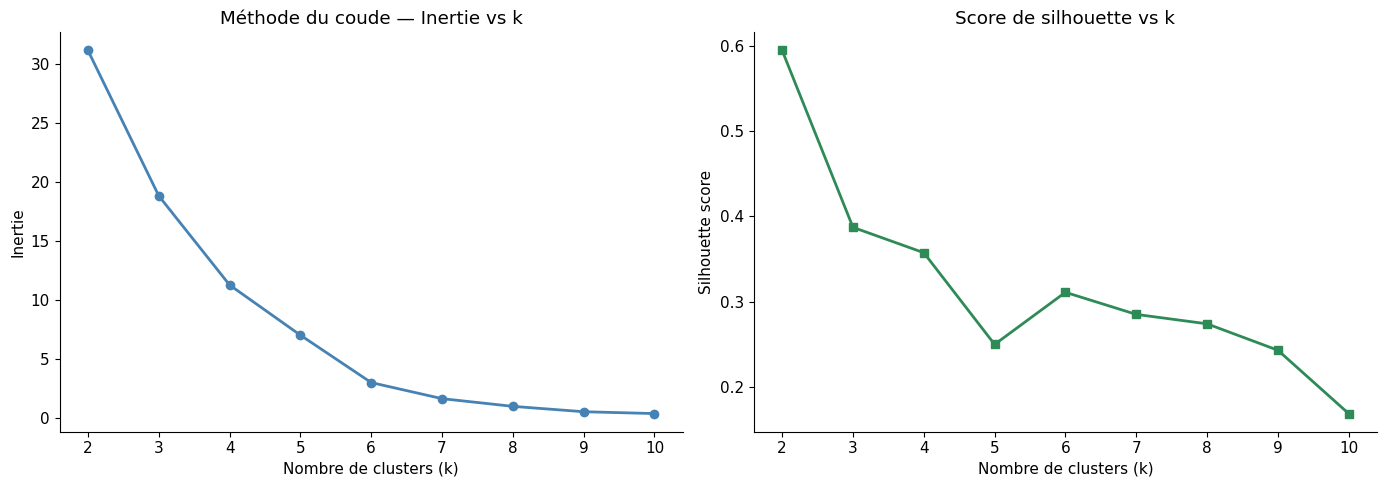

Meilleur score silhouette : 0.5949 pour k = 2


In [5]:
K_RANGE   = range(2, 11)
inerties  = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inertie
axes[0].plot(list(K_RANGE), inerties, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Méthode du coude — Inertie vs k')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_xticks(list(K_RANGE))

# Silhouette
axes[1].plot(list(K_RANGE), silhouettes, marker='s', color='seagreen', linewidth=2)
axes[1].set_title('Score de silhouette vs k')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

k_optimal = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f'Meilleur score silhouette : {max(silhouettes):.4f} pour k = {k_optimal}')

In [6]:
# Modifier k_optimal ici si vous préférez un autre k d'après la méthode du coude
K_OPTIMAL = k_optimal
print(f'K retenu pour K-Means : {K_OPTIMAL}')

K retenu pour K-Means : 2


---
## 4. K-Means avec k optimal

In [7]:
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=20)
kmeans.fit(X_scaled)

df_cluster['cluster'] = kmeans.labels_

print(f'✓ K-Means entraîné avec k = {K_OPTIMAL}')
print(f'  Inertie finale : {kmeans.inertia_:.2f}')
print()
print('Répartition des classes par cluster :')
print(df_cluster.groupby('cluster')['l_atc1'].count().rename('nb_classes').to_string())

✓ K-Means entraîné avec k = 2
  Inertie finale : 31.12

Répartition des classes par cluster :
cluster
0    13
1     1


In [8]:
# Centres des clusters (dans l'espace normalisé)
centres = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
).round(2)
centres.index.name = 'cluster'

print('Centres des clusters (valeurs réelles) :')
centres

Centres des clusters (valeurs réelles) :


,rem_moy,boites_moy,cout_boite,taux_croissance
cluster,,,,
0,1.224845e+09,1.780431e+08,10.26,1.93
1,5.735704e+09,1.824193e+07,314.42,9.66


---
## 5. Visualisations

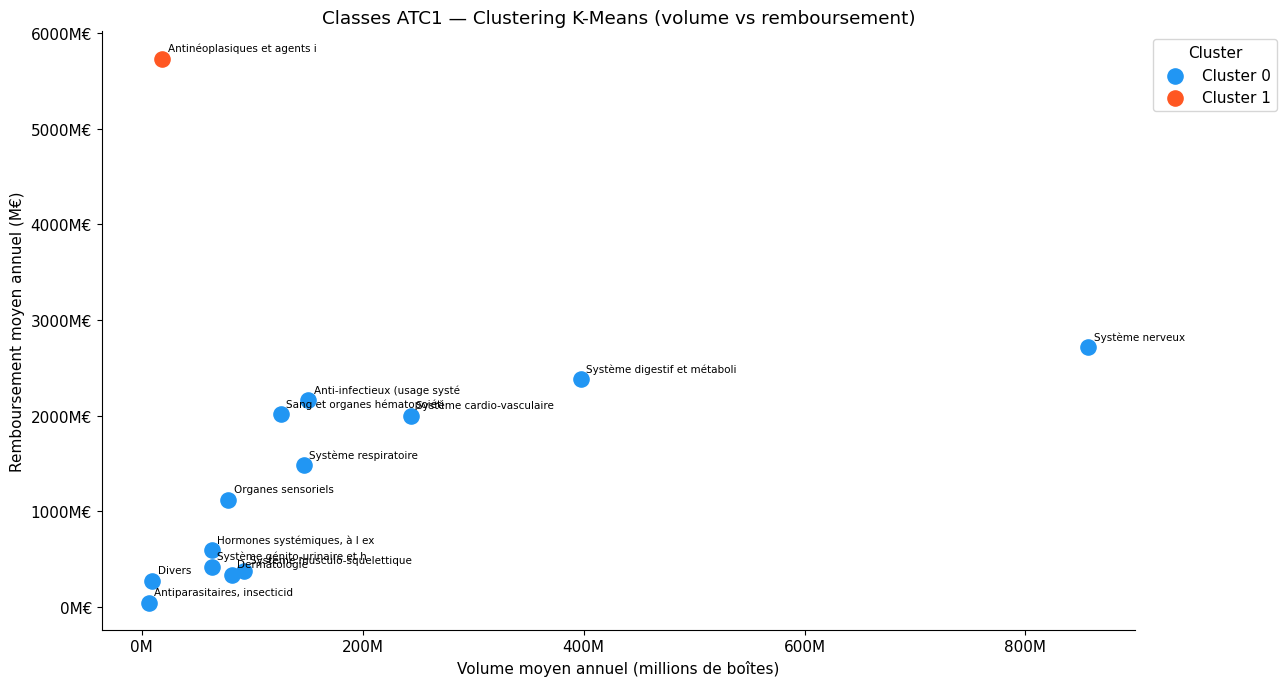

In [9]:
# Scatter : boites_moy vs rem_moy, coloré par cluster
fig, ax = plt.subplots(figsize=(13, 7))

for c in sorted(df_cluster['cluster'].unique()):
    sub = df_cluster[df_cluster['cluster'] == c]
    ax.scatter(
        sub['boites_moy'] / 1e6,
        sub['rem_moy']    / 1e6,
        color=PALETTE[c], s=120, zorder=3, label=f'Cluster {c}'
    )
    for _, row in sub.iterrows():
        ax.annotate(
            row['l_atc1'][:28],
            (row['boites_moy'] / 1e6, row['rem_moy'] / 1e6),
            fontsize=7.5, ha='left', va='bottom',
            xytext=(4, 4), textcoords='offset points'
        )

ax.set_xlabel('Volume moyen annuel (millions de boîtes)')
ax.set_ylabel('Remboursement moyen annuel (M€)')
ax.set_title('Classes ATC1 — Clustering K-Means (volume vs remboursement)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M€'))
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

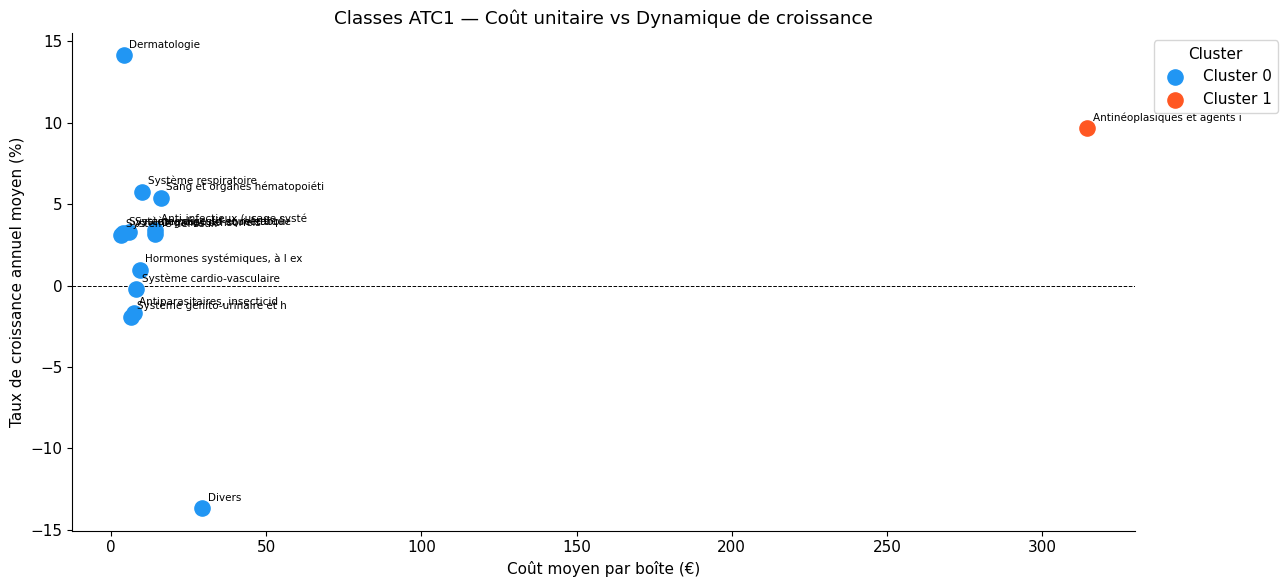

In [10]:
# Scatter : coût/boîte vs taux de croissance, coloré par cluster
fig, ax = plt.subplots(figsize=(13, 6))

for c in sorted(df_cluster['cluster'].unique()):
    sub = df_cluster[df_cluster['cluster'] == c]
    ax.scatter(
        sub['cout_boite'],
        sub['taux_croissance'],
        color=PALETTE[c], s=120, zorder=3, label=f'Cluster {c}'
    )
    for _, row in sub.iterrows():
        ax.annotate(
            row['l_atc1'][:28],
            (row['cout_boite'], row['taux_croissance']),
            fontsize=7.5, ha='left', va='bottom',
            xytext=(4, 4), textcoords='offset points'
        )

ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_xlabel('Coût moyen par boîte (€)')
ax.set_ylabel('Taux de croissance annuel moyen (%)')
ax.set_title('Classes ATC1 — Coût unitaire vs Dynamique de croissance')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

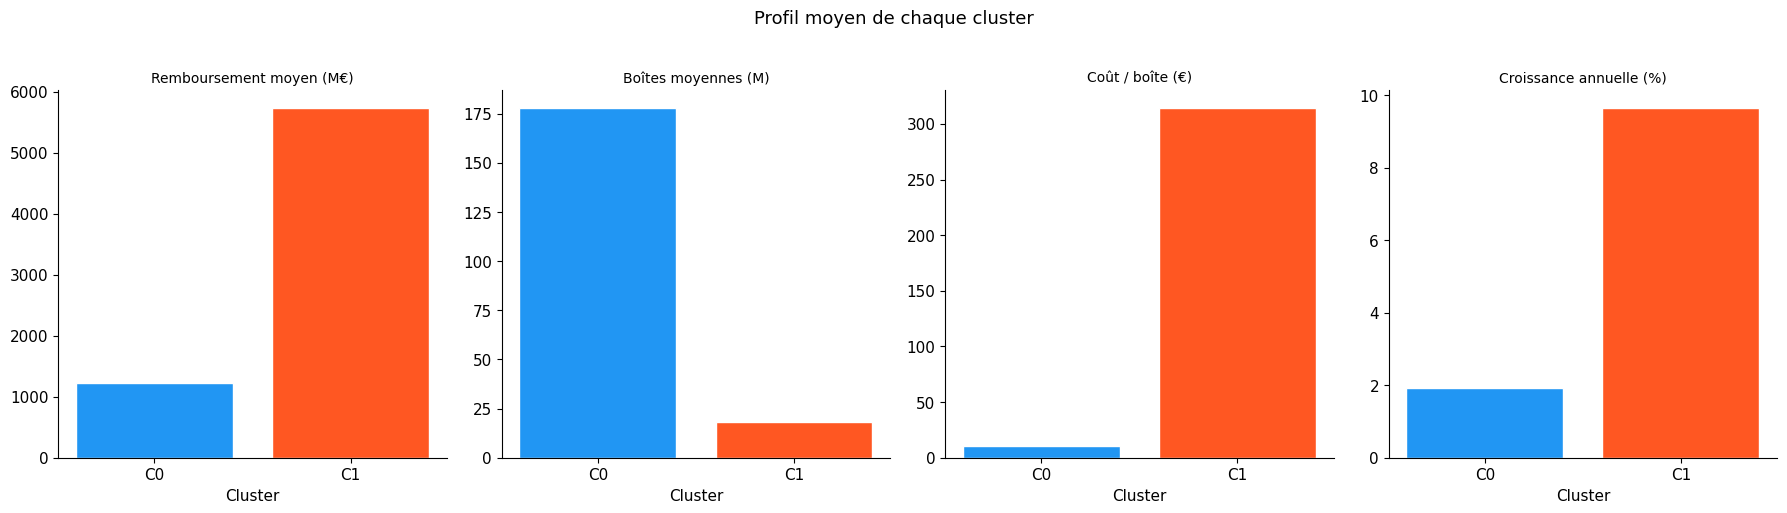

In [11]:
# Barplot : profil moyen de chaque cluster sur les 4 variables
profils = df_cluster.groupby('cluster')[features].mean()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titres = ['Remboursement moyen (M€)', 'Boîtes moyennes (M)', 'Coût / boîte (€)', 'Croissance annuelle (%)']
diviseurs = [1e6, 1e6, 1, 1]

for ax, col, titre, div in zip(axes, features, titres, diviseurs):
    vals   = profils[col] / div
    colors = [PALETTE[c] for c in profils.index]
    ax.bar([f'C{c}' for c in profils.index], vals, color=colors, edgecolor='white')
    ax.set_title(titre, fontsize=10)
    ax.set_xlabel('Cluster')

plt.suptitle('Profil moyen de chaque cluster', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Tableau : classes ATC dans chaque cluster
print('=== COMPOSITION DES CLUSTERS ===')
for c in sorted(df_cluster['cluster'].unique()):
    classes = df_cluster[df_cluster['cluster'] == c]['l_atc1'].tolist()
    print(f'\nCluster {c} ({len(classes)} classe(s)) :')
    for cl in classes:
        row = df_cluster[df_cluster['l_atc1'] == cl].iloc[0]
        print(f'  • {cl[:45]:<45}  rem={row["rem_moy"]/1e6:6.1f}M€  '
              f'boites={row["boites_moy"]/1e6:5.1f}M  '
              f'coût/bte={row["cout_boite"]:6.1f}€  '
              f'croiss={row["taux_croissance"]:+.1f}%')

=== COMPOSITION DES CLUSTERS ===

Cluster 0 (13 classe(s)) :
  • Anti-infectieux (usage systémique)             rem=2159.6M€  boites=150.7M  coût/bte=  14.3€  croiss=+3.4%
  • Antiparasitaires, insecticides et répulsifs    rem=  45.7M€  boites=  6.2M  coût/bte=   7.4€  croiss=-1.7%
  • Dermatologie                                   rem= 336.3M€  boites= 81.4M  coût/bte=   4.1€  croiss=+14.1%
  • Divers                                         rem= 273.5M€  boites=  9.3M  coût/bte=  29.5€  croiss=-13.7%
  • Hormones systémiques, à l exclusion des hormo  rem= 591.5M€  boites= 63.2M  coût/bte=   9.4€  croiss=+1.0%
  • Organes sensoriels                             rem=1121.2M€  boites= 78.3M  coût/bte=  14.3€  croiss=+3.2%
  • Sang et organes hématopoiétiques               rem=2016.1M€  boites=125.6M  coût/bte=  16.0€  croiss=+5.4%
  • Système cardio-vasculaire                      rem=2001.8M€  boites=243.3M  coût/bte=   8.2€  croiss=-0.2%
  • Système digestif et métabolisme              

---
## 6. Interprétation économique des clusters

> Les profils ci-dessous se basent sur les centres des clusters.  
> Adaptez les descriptions selon les valeurs réelles affichées dans la cellule précédente.

---

In [13]:
# Génération automatique des profils basée sur les centres réels
def profil_auto(row):
    rem   = row['rem_moy']
    bte   = row['boites_moy']
    cout  = row['cout_boite']
    croiss= row['taux_croissance']

    rem_med  = df_cluster['rem_moy'].median()
    bte_med  = df_cluster['boites_moy'].median()
    cout_med = df_cluster['cout_boite'].median()

    vol  = 'fort volume' if bte > bte_med else 'faible volume'
    dep  = 'dépenses élevées' if rem > rem_med else 'dépenses faibles'
    prix = 'prix unitaire élevé' if cout > cout_med else 'prix unitaire modéré'
    dyn  = f'croissance +{croiss:.1f}%/an' if croiss > 2 else (
           f'déclin {croiss:.1f}%/an' if croiss < -1 else 'stable')

    return f'{vol}, {dep}, {prix}, {dyn}'

print('=== PROFIL DE CHAQUE CLUSTER ===')
print()
for c in sorted(df_cluster['cluster'].unique()):
    centre = centres.iloc[c]
    classes = df_cluster[df_cluster['cluster'] == c]['l_atc1'].tolist()
    p = profil_auto(centre)
    print(f'CLUSTER {c} — {p}')
    print(f'  Classes : {", ".join([cl[:30] for cl in classes])}')
    print()

=== PROFIL DE CHAQUE CLUSTER ===

CLUSTER 0 — fort volume, dépenses faibles, prix unitaire élevé, stable
  Classes : Anti-infectieux (usage systémi, Antiparasitaires, insecticides, Dermatologie, Divers, Hormones systémiques, à l excl, Organes sensoriels, Sang et organes hématopoiétiqu, Système cardio-vasculaire, Système digestif et métabolism, Système génito-urinaire et hor, Système musculo-squelettique, Système nerveux, Système respiratoire

CLUSTER 1 — faible volume, dépenses élevées, prix unitaire élevé, croissance +9.7%/an
  Classes : Antinéoplasiques et agents imm



### Grille d'interprétation

| Profil type | Caractéristiques | Exemple typique |
|---|---|---|
| **Masse / bas coût** | Volume très élevé, remboursement modéré, prix/boîte faible | Cardiovasculaire, système nerveux (génériques) |
| **Premium / spécialisé** | Faible volume, remboursement élevé, prix/boîte très fort | Oncologie, maladies rares |
| **Croissance dynamique** | Volume en hausse, prix en progression | Antidiabétiques (GLP-1), immunologie |
| **Déclin structurel** | Volume en baisse, souvent génériqué | Antibiotiques anciens, antiulcéreux |

---

### Ce que révèle le clustering pour la politique de santé

**Cluster à fort coût / faible volume** : ce sont les leviers principaux de maîtrise des dépenses.  
Une négociation de prix CEPS ou une extension des biosimilaires aurait un impact budgétaire fort  
pour un impact médical limité en termes de patients concernés.

**Cluster à fort volume / bas coût** : généralement déjà génériqués. Le potentiel d'économie  
est faible sur le prix mais fort sur la **pertinence des prescriptions** (déprescription).

**Cluster en croissance** : signale les nouvelles classes thérapeutiques dont les remboursements  
vont peser de plus en plus sur le budget de l'Assurance Maladie.  
Ces classes méritent un suivi renforcé.

---
## 7. Export

In [14]:
# Table complète avec cluster et profil
df_export = df_cluster.copy()
df_export['profil'] = df_export['cluster'].map(
    {c: profil_auto(centres.iloc[c]) for c in sorted(df_cluster['cluster'].unique())}
)
df_export = df_export.sort_values(['cluster', 'rem_moy'], ascending=[True, False])
df_export = df_export.round({'rem_moy': 0, 'boites_moy': 0,
                              'cout_boite': 2, 'taux_croissance': 2})

out = OUTPUTS_DIR / 'clustering_atc1.csv'
df_export.to_csv(out, index=False, encoding='utf-8')

print('✓ Exporté :', out)
print(f'  {len(df_export)} classes ATC1 dans {K_OPTIMAL} clusters')
print()
df_export

✓ Exporté : C:\Users\Enes\projet_pharma\outputs\clustering_atc1.csv
  14 classes ATC1 dans 2 clusters



,l_atc1,rem_moy,boites_moy,cout_boite,taux_croissance,cluster,profil
12,Système nerveux,2.716758e+09,856968322.0,3.17,3.10,0,"fort volume, dépenses faibles, prix unitaire é..."
9,Système digestif et métabolisme,2.381737e+09,397246242.0,6.00,3.27,0,"fort volume, dépenses faibles, prix unitaire é..."
0,Anti-infectieux (usage systémique),2.159636e+09,150655781.0,14.33,3.44,0,"fort volume, dépenses faibles, prix unitaire é..."
7,Sang et organes hématopoiétiques,2.016149e+09,125627713.0,16.05,5.39,0,"fort volume, dépenses faibles, prix unitaire é..."
8,Système cardio-vasculaire,2.001808e+09,243296619.0,8.23,-0.22,0,"fort volume, dépenses faibles, prix unitaire é..."
13,Système respiratoire,1.483462e+09,146572378.0,10.12,5.77,0,"fort volume, dépenses faibles, prix unitaire é..."
6,Organes sensoriels,1.121153e+09,78334426.0,14.31,3.20,0,"fort volume, dépenses faibles, prix unitaire é..."
5,"Hormones systémiques, à l exclusion des hormon...",5.915372e+08,63209126.0,9.36,0.97,0,"fort volume, dépenses faibles, prix unitaire é..."
10,Système génito-urinaire et hormones sexuelles,4.170754e+08,63114580.0,6.61,-1.90,0,"fort volume, dépenses faibles, prix unitaire é..."
11,Système musculo-squelettique,3.782200e+08,92705300.0,4.08,3.25,0,"fort volume, dépenses faibles, prix unitaire é..."
